In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [7]:
df = pd.read_csv('titanic_toy.csv')

In [8]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [10]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [11]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

In [12]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [14]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [15]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

In [16]:
mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [17]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Age'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Age'].fillna(mean_fare)

In [18]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
148,36.5,26.0000,2,36.50,36.500000,36.5000,36.500000
32,NaN,7.7500,0,28.75,29.785904,14.4583,32.617597
729,25.0,7.9250,1,25.00,25.000000,25.0000,25.000000
625,61.0,32.3208,0,61.00,61.000000,61.0000,61.000000
344,36.0,13.0000,0,36.00,36.000000,36.0000,36.000000


In [19]:
print('Original Age Variable variance:', X_train['Age'].var())
print('Age Variance after median imputation:',X_train['Age_median'].var())
print('Age Variance after mean imputation:',X_train['Age_mean'].var())

Original Age Variable variance: 204.34951339046142
Age Variance after median imputation: 161.98956633460548
Age Variance after mean imputation: 161.81262452718676


In [20]:
print('Original Fare Variable variance:', X_train['Fare'].var())
print('fare Variance after median imputation:',X_train['Fare_median'].var())
print('Fare Variance after mean imputation:',X_train['Fare_mean'].var())

Original Fare Variable variance: 2448.1979137063163
fare Variance after median imputation: 200.55085535155044
Fare Variance after mean imputation: 163.13478280526172


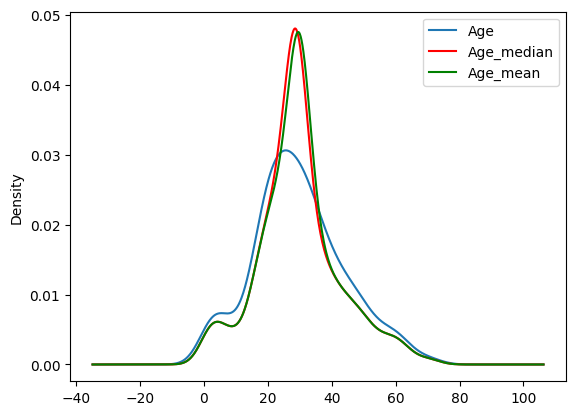

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable impute with the medain
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')

# variable impute with  the mean
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')

# add legends 
lines, labels= ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

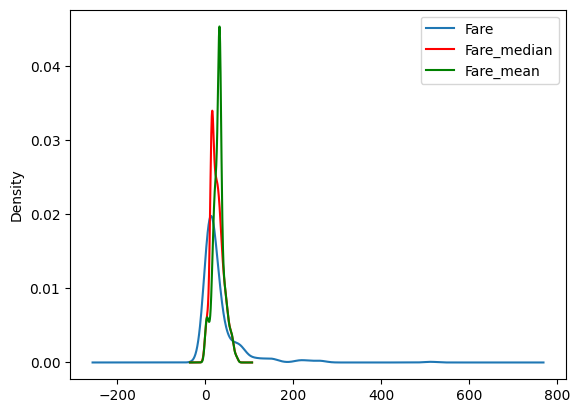

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable impute with the medain
X_train['Fare_median'].plot(kind='kde',ax=ax,color='red')

# variable impute with  the mean
X_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')

# add legends 
lines, labels= ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [26]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,204.349513,204.349513
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,90.432552,49.169279
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,-4.649792,-5.237797
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,164.430718,161.328946
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,161.812625,161.812625
Fare_median,204.349513,90.432552,-4.649792,164.430718,161.812625,200.550855,154.655944
Fare_mean,204.349513,49.169279,-5.237797,161.328946,161.812625,154.655944,163.134783


In [27]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,1.000000,1.000000
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,0.128809,0.077538
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,-0.198528,-0.247957
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.912278,0.992420
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.898243,0.995939
Fare_median,1.000000,0.128809,-0.198528,0.912278,0.898243,1.000000,0.855029
Fare_mean,1.000000,0.077538,-0.247957,0.992420,0.995939,0.855029,1.000000


<Axes: >

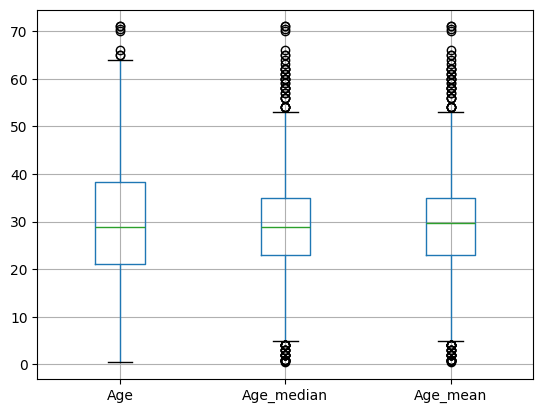

In [28]:
X_train[['Age','Age_median','Age_mean']].boxplot()

# using Sklearn

In [30]:
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [36]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [37]:
trf =ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [38]:
trf.fit(X_train)

c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [39]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [41]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [42]:
X_train = trf.transform(X_train)

In [43]:
X_test = trf.transform(X_test)

In [44]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

# Using Arbittrary value Imputation

In [47]:
X_train, X_train,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [49]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [50]:
print('Original Age Variable variance:', X_train['Age'].var())
print('Age Variance after 99 wala imputation:',X_train['Age_99'].var())
print('Age Variance after -1 wala imputation:',X_train['Age_minus1'].var())

Original Age Variable variance: 237.50093573154362
Age Variance after 99 wala imputation: 860.6790791287427
Age Variance after -1 wala imputation: 324.7533996359299


In [51]:
print('Original Age Variable variance:', X_train['Fare'].var())
print('Age Variance after 999 wala imputation:',X_train['Fare_999'].var())
print('Age Variance after -1 wala imputation:',X_train['Fare_minus1'].var())

Original Age Variable variance: 2872.782499147435
Age Variance after 999 wala imputation: 47729.14407195378
Age Variance after -1 wala imputation: 2776.4996867927707


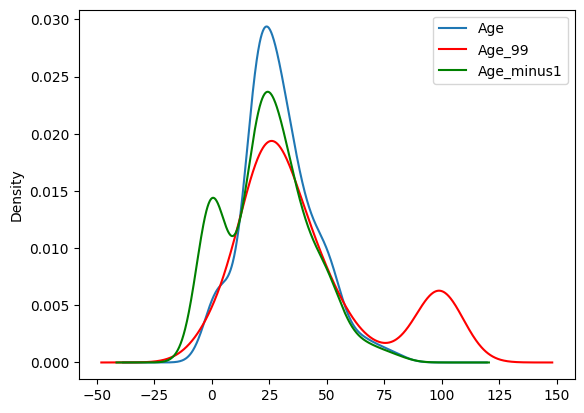

In [54]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the median
X_train['Age_99'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the median
X_train['Age_minus1'].plot(kind='kde',ax=ax,color='green')

# add legends
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels, loc='best')

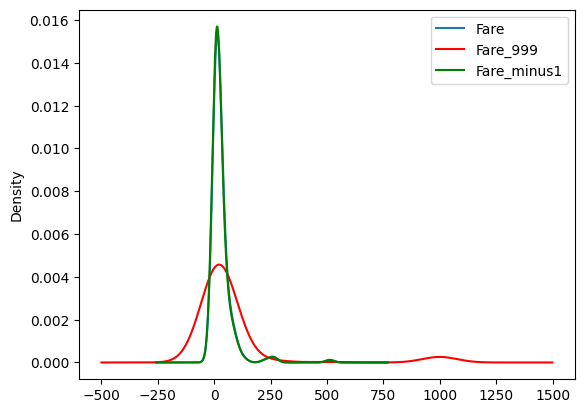

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)

# variable imputed with the median
X_train['Fare_999'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the median
X_train['Fare_minus1'].plot(kind='kde',ax=ax,color='green')

# add legends
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels, loc='best')

In [56]:
X_train.cov

<bound method DataFrame.cov of       Age     Fare  Family  Age_99  Age_minus1  Fare_999  Fare_minus1
707  42.0  26.2875       0    42.0        42.0   26.2875      26.2875
37   21.0   8.0500       0    21.0        21.0    8.0500       8.0500
615  24.0  65.0000       3    24.0        24.0   65.0000      65.0000
169  28.0  56.4958       0    28.0        28.0   56.4958      56.4958
68   17.0   7.9250       6    17.0        17.0    7.9250       7.9250
..    ...      ...     ...     ...         ...       ...          ...
89   24.0   8.0500       0    24.0        24.0    8.0500       8.0500
80   22.0   9.0000       0    22.0        22.0    9.0000       9.0000
846   NaN  69.5500      10    99.0        -1.0   69.5500      69.5500
870  26.0   7.8958       0    26.0        26.0    7.8958       7.8958
251  29.0      NaN       2    29.0        29.0  999.0000      -1.0000

[179 rows x 7 columns]>

In [57]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.122328,-0.321470,1.000000,1.000000,-0.033861,0.128144
Fare,0.122328,1.000000,0.233762,0.020751,0.114449,1.000000,1.000000
Family,-0.321470,0.233762,1.000000,-0.186910,-0.174310,0.086930,0.222732
Age_99,1.000000,0.020751,-0.186910,1.000000,-0.170073,-0.110457,0.036133
Age_minus1,1.000000,0.114449,-0.174310,-0.170073,1.000000,0.040728,0.110579
Fare_999,-0.033861,1.000000,0.086930,-0.110457,0.040728,1.000000,0.107979
Fare_minus1,0.128144,1.000000,0.222732,0.036133,0.110579,0.107979,1.000000


# Using sklearn

In [58]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [61]:
imputer1 = SimpleImputer(strategy = 'constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [65]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [66]:
trf.fit(X_train)

c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [67]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [68]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [69]:
X_train = trf.transform(X_train)
x_test = trf.transform(X_test)

In [70]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])